In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Ensure we can import our local package
sys.path.append(os.getcwd())
sys.path.append('./..')

from src import solver, plotting, utils, constants as c, utils

# Visualization Settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

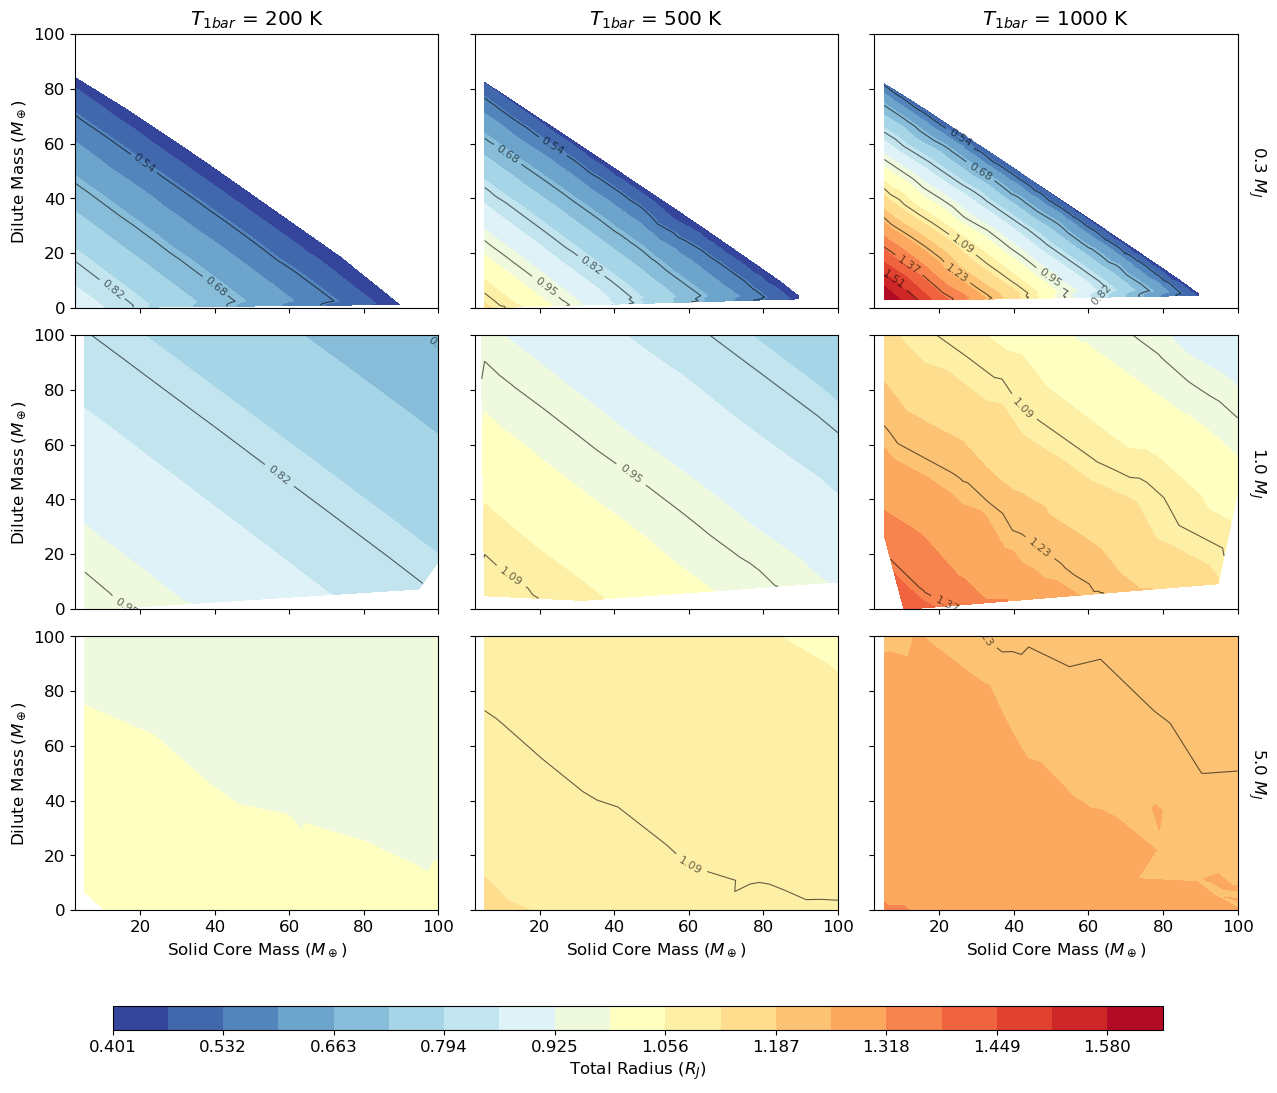

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Read and Clean Data
df = pd.read_csv('../data/equivalence_grid_3x3.csv')
cols_to_convert = ['M_total_Mj', 'M_core_input_Me', 'Z_base', 'M_Z_total_Me', 'R_total_Rj', 'Sigma_dilute', 'target_value', 'T_surf_K']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_convert)
df = df[df['status'] == 'success']

# 2. Calculate Dilute Mass
M_tot_Me = df['M_total_Mj'] * 317.8 
M_env_Me = M_tot_Me - df['M_core_input_Me']
M_base_Z_Me = M_env_Me * df['Z_base']
df['M_dilute_Me'] = df['M_Z_total_Me'] - df['M_core_input_Me'] - M_base_Z_Me

# Avoid minor negative noise from integration
df['M_dilute_Me'] = np.clip(df['M_dilute_Me'], 0, None) 

# --- NEW: Filter extreme dilute masses to prevent color scale skewing ---
#df = df[df['M_dilute_Me'] <= 100.0]

# --- Define Global Color Levels (post-filtering) ---
r_min = df['R_total_Rj'].min()
r_max = df['R_total_Rj'].max()

global_levels = np.linspace(r_min, r_max, 20)
line_levels = np.linspace(r_min, r_max, 10)
# ---------------------------------------

# 3. Setup the 3x3 Plot (Added sharey=True)
masses_mj = [0.3, 1.0, 5.0]
temps_k = [200.0, 500.0, 1000.0]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for i, m_mj in enumerate(masses_mj):
    for j, t_k in enumerate(temps_k):
        ax = axes[i, j]
        
        target_val_kg = m_mj * 1.898e27 
        panel_df = df[
            np.isclose(df['target_value'], target_val_kg, rtol=1e-3) & 
            (df['T_surf_K'] == t_k)
        ]
        
        if len(panel_df) > 5: 
            contour = ax.tricontourf(
                panel_df['M_core_input_Me'], 
                panel_df['M_dilute_Me'], 
                panel_df['R_total_Rj'], 
                levels=global_levels, 
                cmap='RdYlBu_r'
            )
            lines = ax.tricontour(
                panel_df['M_core_input_Me'], panel_df['M_dilute_Me'], panel_df['R_total_Rj'], 
                levels=line_levels, colors='black', alpha=0.6, linewidths=0.8
            )
            ax.clabel(lines, inline=True, fontsize=8, fmt='%1.2f')
            
        # --- NEW: Hard limit the Y-axis to 100 Earth Masses ---
        ax.set_ylim(0, 100)
        
        # Labels and formatting
        if i == 0: ax.set_title(f"$T_{{1 bar}}$ = {int(t_k)} K")
        if j == 2: ax.text(1.05, 0.5, f"{m_mj} $M_J$", transform=ax.transAxes, rotation=270, va='center', ha='center', fontsize=12)
        if i == 2: ax.set_xlabel("Solid Core Mass ($M_\oplus$)")
        if j == 0: ax.set_ylabel("Dilute Mass ($M_\oplus$)")

# Add a colorbar at the bottom
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Total Radius ($R_J$)')

plt.subplots_adjust(bottom=0.15, wspace=0.1, hspace=0.1)
plt.savefig("../figures/core_equivalence_grid.pdf", bbox_inches='tight')
plt.show()

/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/ipykernel_19076/1998675720.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sens_df, x='Elasticity (%)', y='Parameter', palette=colors, ax=ax1)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/cwilkinson/anaconda3/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/ipykernel_19076/1998675720.py:86: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=target,


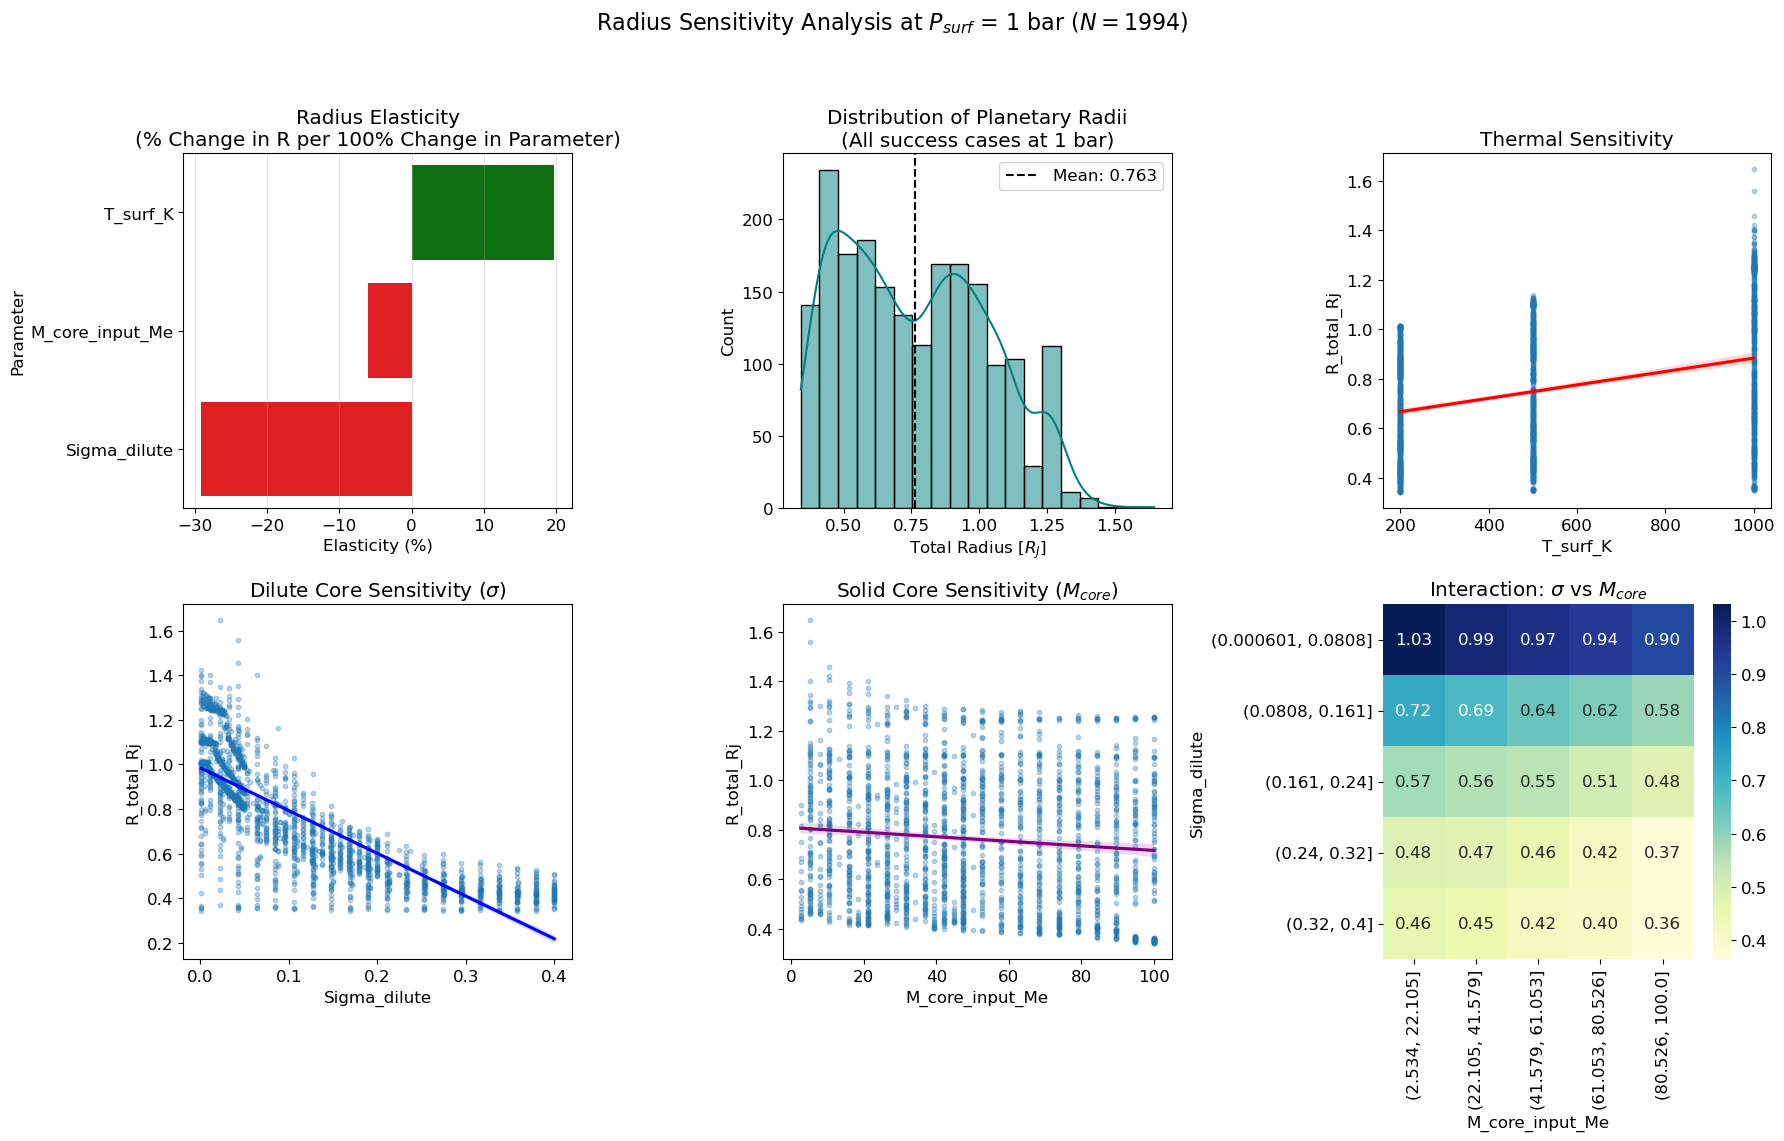


--- Numerical Sensitivity Summary (at 1 bar) ---
      Parameter  Slope (dR/dX)  Elasticity (%)  Correlation
       T_surf_K       0.000271       19.757257     0.329355
M_core_input_Me      -0.000922       -5.968529    -0.098349
   Sigma_dilute      -1.917176      -29.111584    -0.784984


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load and Prepare Data
df = pd.read_csv('../data/equivalence_grid_3x3.csv')
df = df[df['status'] != 'failed'].copy()

# Filter specifically for the 1 bar pressure point
df = df[df['P_surf_bar'] == 1].copy()

# --- FIX: Column Cleaning ---
# Check which columns actually exist to avoid KeyErrors (e.g., Z_base)
potential_cols = ['P_surf_bar', 'T_surf_K', 'M_core_input_Me', 'Sigma_dilute', 'Z_base', 'R_total_Rj']
cols_to_fix = [c for c in potential_cols if c in df.columns]

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

# Parameters to evaluate: Remove P_surf_bar because it is now constant
# Also ensure Z_base is only included if it exists in your CSV
params_to_test = [p for p in ['T_surf_K', 'M_core_input_Me', 'Sigma_dilute', 'Z_base'] if p in df.columns]
target = 'R_total_Rj'

# 2. Calculate Sensitivity Coefficients (Slopes)
sensitivities = []
for p in params_to_test:
    # Safety check: skip if the parameter has zero variance
    if df[p].nunique() <= 1:
        continue
        
    slope, intercept, r_val, p_val, std_err = stats.linregress(df[p], df[target])
    # Elasticity: (slope * mean_param) / mean_radius
    elasticity = slope * (df[p].mean() / df[target].mean())
    sensitivities.append({
        'Parameter': p,
        'Slope (dR/dX)': slope,
        'Elasticity (%)': elasticity * 100,
        'Correlation': r_val
    })

sens_df = pd.DataFrame(sensitivities).sort_values(by='Elasticity (%)', ascending=False)

# 3. Visualization
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f"Radius Sensitivity Analysis at $P_{{surf}}$ = 1 bar ($N={len(df)}$)", fontsize=16)
gs = fig.add_gridspec(2, 3)

# --- Plot 1: Global Sensitivity (Elasticity) ---
ax1 = fig.add_subplot(gs[0, 0])
if not sens_df.empty:
    colors = ['red' if x < 0 else 'green' for x in sens_df['Elasticity (%)']]
    sns.barplot(data=sens_df, x='Elasticity (%)', y='Parameter', palette=colors, ax=ax1)
    ax1.set_title("Radius Elasticity\n(% Change in R per 100% Change in Parameter)")
ax1.grid(axis='x', alpha=0.3)

# --- Plot 2: Radius Distribution at 1 Bar (Replaced Boxplot) ---
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df[target], kde=True, color='teal', ax=ax2)
ax2.axvline(df[target].mean(), color='k', linestyle='--', label=f"Mean: {df[target].mean():.3f}")
ax2.set_title("Distribution of Planetary Radii\n(All success cases at 1 bar)")
ax2.set_xlabel("Total Radius [$R_J$]")
ax2.legend()

# --- Plot 3: T_surf vs Radius ---
ax3 = fig.add_subplot(gs[0, 2])
sns.regplot(data=df, x='T_surf_K', y=target, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'}, ax=ax3)
ax3.set_title("Thermal Sensitivity")

# --- Plot 4: Sigma vs Radius ---
ax4 = fig.add_subplot(gs[1, 0])
sns.regplot(data=df, x='Sigma_dilute', y=target, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'blue'}, ax=ax4)
ax4.set_title("Dilute Core Sensitivity ($\sigma$)")

# --- Plot 5: Core Mass vs Radius ---
ax5 = fig.add_subplot(gs[1, 1])
sns.regplot(data=df, x='M_core_input_Me', y=target, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'purple'}, ax=ax5)
ax5.set_title("Solid Core Sensitivity ($M_{core}$)")

# --- Plot 6: Interaction Heatmap ---
ax6 = fig.add_subplot(gs[1, 2])
pivot = df.pivot_table(values=target, 
                       index=pd.cut(df['Sigma_dilute'], 5), 
                       columns=pd.cut(df['M_core_input_Me'], 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax6)
ax6.set_title("Interaction: $\sigma$ vs $M_{core}$")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Print Summary Table
print("\n--- Numerical Sensitivity Summary (at 1 bar) ---")
if not sens_df.empty:
    print(sens_df[['Parameter', 'Slope (dR/dX)', 'Elasticity (%)', 'Correlation']].to_string(index=False))
else:
    print("No variable parameters found for regression.")

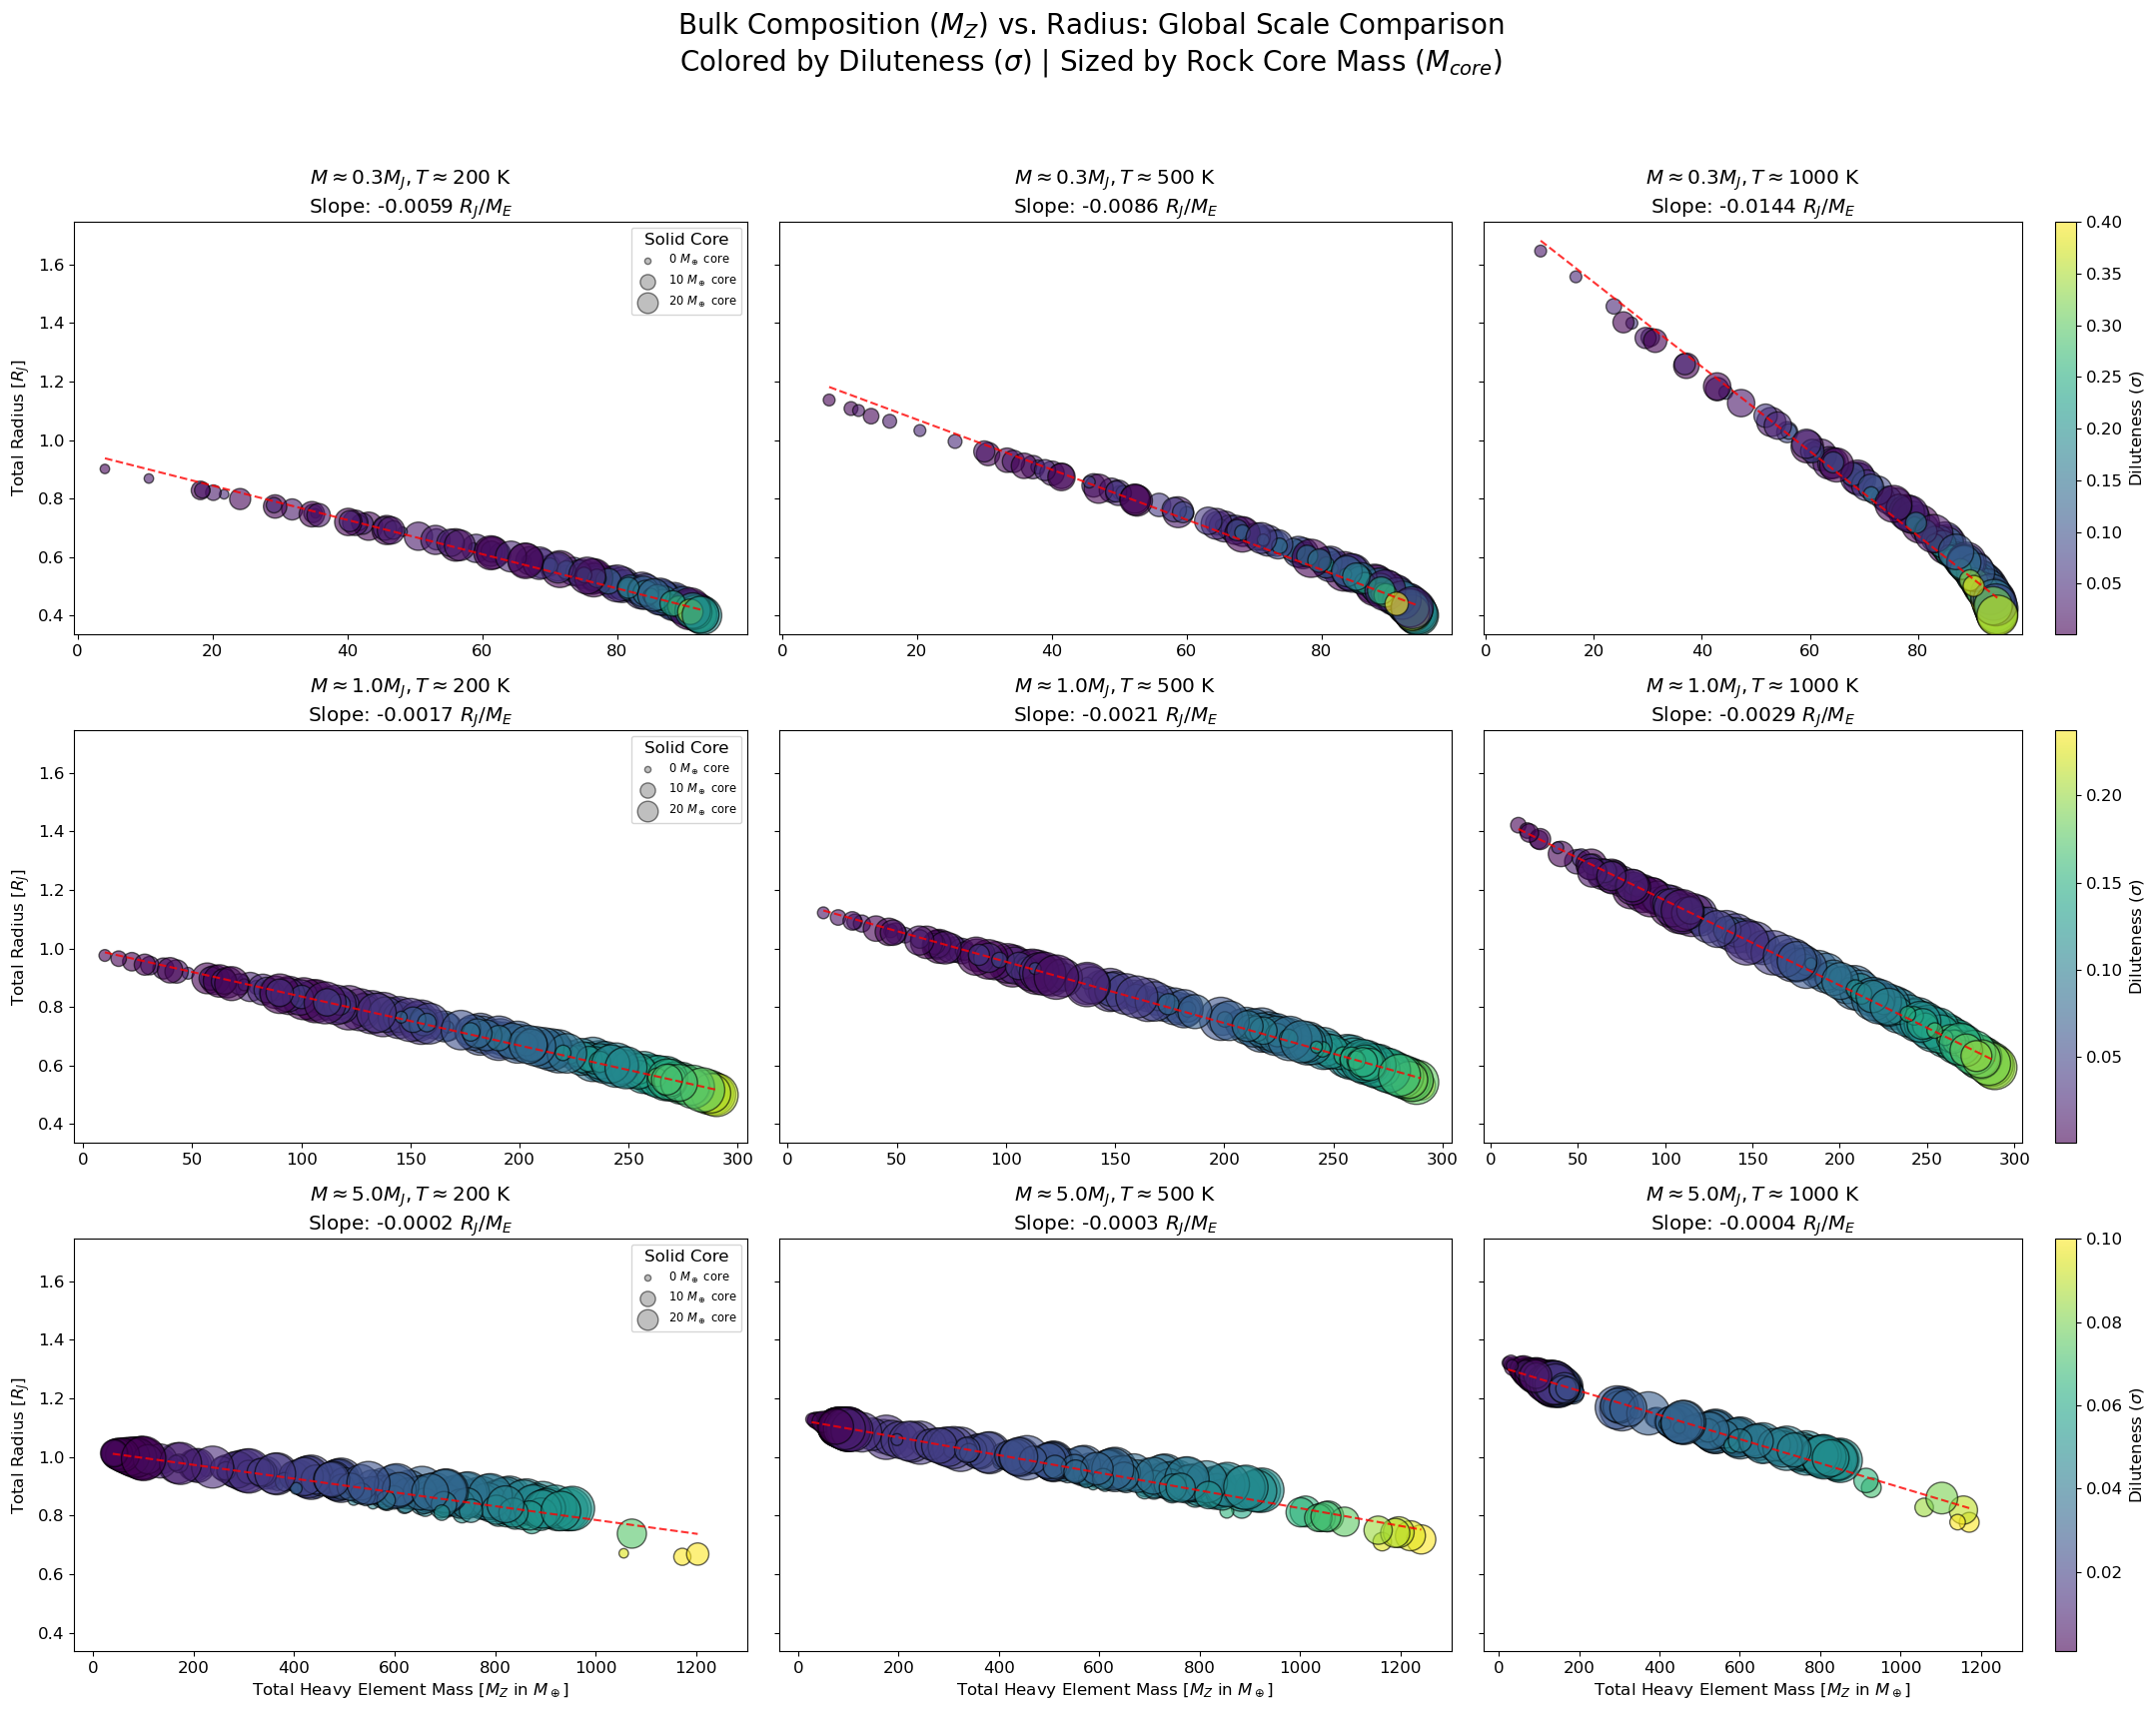

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# 1. Read and Clean Data
df = pd.read_csv('../data/equivalence_grid_3x3.csv')
cols_to_convert = ['M_total_Mj', 'M_core_input_Me', 'Z_base', 'M_Z_total_Me', 'R_total_Rj', 'Sigma_dilute', 'target_value', 'T_surf_K']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_convert)
df = df[df['status'] == 'success']

# 2. Calculate Dilute Mass
M_tot_Me = df['M_total_Mj'] * 317.8 
M_env_Me = M_tot_Me - df['M_core_input_Me']
M_base_Z_Me = M_env_Me * df['Z_base']
df['M_dilute_Me'] = df['M_Z_total_Me'] - df['M_core_input_Me'] - M_base_Z_Me

# Avoid minor negative noise from integration
df['M_dilute_Me'] = np.clip(df['M_dilute_Me'], 0, None) 

# --- NEW: Filter extreme dilute masses to prevent color scale skewing ---
#df = df[df['M_dilute_Me'] <= 100.0]

# --- Define Global Color Levels (post-filtering) ---
r_min = df['R_total_Rj'].min()
r_max = df['R_total_Rj'].max()


# Ensure numeric types
cols = ['M_core_input_Me', 'M_Z_total_Me', 'R_total_Rj', 'T_surf_K', 'M_total_Mj', 'Sigma_dilute']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['M_Z_total_Me', 'R_total_Rj', 'M_core_input_Me'])

# --- CONFIGURATION ---
target_temps = [200, 500, 1000]
target_masses = [0.3, 1.0, 5.0]
t_window = 30  
m_window_ratio = 0.15 

# MODIFICATION: Changed sharey='row' to sharey=True for global comparison
fig, axes = plt.subplots(3, 3, figsize=(22, 18), sharex='row', sharey=True)

for i, m_target in enumerate(target_masses):
    for j, t_target in enumerate(target_temps):
        ax = axes[i, j]
        
        m_low, m_high = m_target * (1 - m_window_ratio), m_target * (1 + m_window_ratio)
        mask = (
            (df['P_surf_bar'] == 1.0) &
            (df['M_total_Mj'].between(m_low, m_high)) &
            (df['T_surf_K'].between(t_target - t_window, t_target + t_window))
        )
        df_slice = df[mask].copy()
        
        if len(df_slice) > 5:
            x = df_slice['M_Z_total_Me'].values.astype(float)
            y = df_slice['R_total_Rj'].values.astype(float)
            
            # Sizing by Solid Core Mass
            sizes = 20 + (df_slice['M_core_input_Me'].values.astype(float) * 10)
            
            # Color by Sigma, size by Core Mass
            scatter = ax.scatter(x, y, c=df_slice['Sigma_dilute'], cmap='viridis', 
                                s=sizes, edgecolor='k', alpha=0.6)
            
            # Regression line for bulk density trend
            slope, intercept, r_val, _, _ = stats.linregress(x, y)
            x_range = np.linspace(x.min(), x.max(), 10)
            ax.plot(x_range, slope*x_range + intercept, color='red', linestyle='--', alpha=0.8)
            
            ax.set_title(f"$M \\approx {m_target} M_J, T \\approx {t_target}$ K\nSlope: {slope:.4f} $R_J/M_E$")
            
            if i == 2: ax.set_xlabel(r'Total Heavy Element Mass [$M_Z$ in $M_\oplus$]')
            if j == 0: ax.set_ylabel(r'Total Radius [$R_J$]')
            
            if j == 0:
                for s_val in [0, 10, 20]:
                    ax.scatter([], [], c='gray', alpha=0.5, s=20 + s_val*10,
                               label=f'{s_val} $M_\oplus$ core', edgecolor='k')
                ax.legend(title="Solid Core", loc='upper right', fontsize='x-small')

            if j == 2:
                fig.colorbar(scatter, ax=ax, label='Diluteness ($\sigma$)')
        else:
            ax.set_title(f"$M \\approx {m_target} M_J, T \\approx {t_target}$ K\n(Insufficient Data)")

plt.suptitle("Bulk Composition ($M_Z$) vs. Radius: Global Scale Comparison\nColored by Diluteness ($\sigma$) | Sized by Rock Core Mass ($M_{core}$)", 
             fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Ensure directory exists and save
output_dir = '../figures/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'mz_vs_radius_grid.pdf'), bbox_inches='tight')
plt.show()

--------


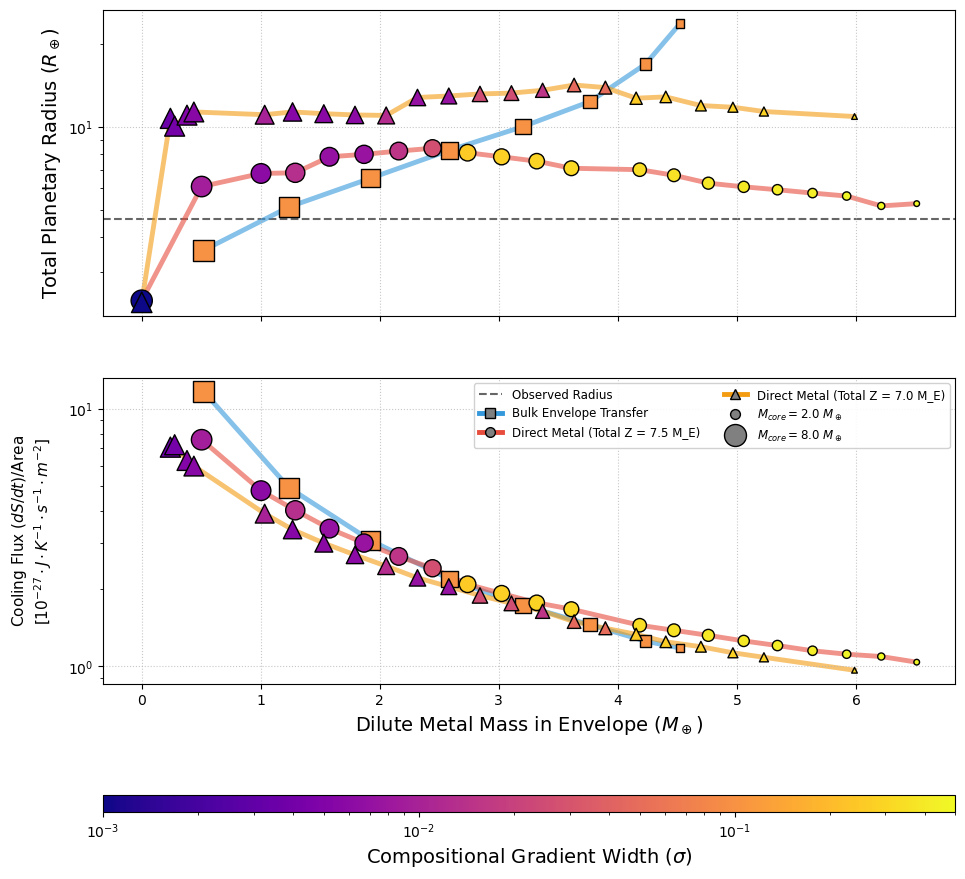

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
from matplotlib.lines import Line2D

# =============================================================================
# CONFIGURATION
# =============================================================================
RESULTS_FILE = "../data/kepler11e_sweep_results.csv"
OUTPUT_PLOT = "../figures/kepler11e_multi_track_thermal_blanketing.pdf"

# Removed the 7.5 M_E track as requested
MODES = [
    'Bulk Envelope Transfer',
    'Direct Metal (Total Z = 7.5 M_E)',
    'Direct Metal (Total Z = 7.0 M_E)',
    'Direct Metal (Total Z = 6.0 M_E)',
    'Direct Metal (Total Z = 5.0 M_E)'
]

COLORS_MAP = {
    'Bulk Envelope Transfer': '#3498db',           # Blue
    'Direct Metal (Total Z = 7.5 M_E)': '#e74c3c', # Red
    'Direct Metal (Total Z = 7.0 M_E)': '#f39c12', # Orange
    'Direct Metal (Total Z = 6.0 M_E)': '#9b59b6', # Purple
    'Direct Metal (Total Z = 5.0 M_E)': '#7f8c8d'  # Gray/Slate
}

MARKERS = {
    'Bulk Envelope Transfer': 's', 
    'Direct Metal (Total Z = 7.5 M_E)': 'o',
    'Direct Metal (Total Z = 7.0 M_E)': '^',
    'Direct Metal (Total Z = 6.0 M_E)': 'D',
    'Direct Metal (Total Z = 5.0 M_E)': '<',
}

# =============================================================================
# PLOTTING
# =============================================================================
if not os.path.exists(RESULTS_FILE):
    print(f"[!] Could not find results file at {RESULTS_FILE}")
else:
    df_plot = pd.read_csv(RESULTS_FILE)
    df_plot = df_plot[df_plot['R_total_Re'] < 25.0]
    
    # Equal panel heights [1, 1]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 12), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 1]})

    # Handle Log scale for colorbar including sigma=0
    sigma_min_floor = 1e-3
    sigma_max = df_plot['Sigma_Used'].max()
    norm = colors.LogNorm(vmin=sigma_min_floor, vmax=sigma_max)

    sc1 = None 
    track_legend_handles = []

    # 1. Add Observed Radius handle
    obs_line = ax1.axhline(y=4.67, color='black', linestyle='--', alpha=0.6, label='Observed Radius', zorder=0)
    track_legend_handles.append(obs_line)

    for mode in MODES:
        df_mode = df_plot[df_plot['Transfer_Mode'] == mode].copy()
        if df_mode.empty: continue
        df_mode = df_mode.sort_values(by='M_core_Me', ascending=False)
        
        # Mapping Core Mass to Point Size
        m_min, m_max = 2.0, 8.0
        point_sizes = (df_mode['M_core_Me'] - m_min) / (m_max - m_min) * 200 + 50
        c_values = df_mode['Sigma_Used'].replace(0, sigma_min_floor)

        # Top Panel: Radius
        ax1.plot(df_mode['M_dilute_Me'], df_mode['R_total_Re'], 
                 linestyle='-', color=COLORS_MAP.get(mode, 'gray'), linewidth=3.5, zorder=1, alpha=0.6)
        
        sc1 = ax1.scatter(df_mode['M_dilute_Me'], df_mode['R_total_Re'], 
                          c=c_values, cmap='plasma', norm=norm,
                          marker=MARKERS.get(mode, 'o'), s=point_sizes, edgecolor='black', 
                          linewidth=1.0, zorder=2)

        # Bottom Panel: Cooling Flux (Scaled)
        if 'dt_ds_total' in df_mode.columns:
            ds_dt_mag = np.abs(1.0 / df_mode['dt_ds_total'])
            area_m2 = 4 * np.pi * (df_mode['R_total_Re'] * 6357000.0)**2
            # Scaled for cleaner ticks
            ds_dt_per_area_scaled = (ds_dt_mag / area_m2) * 1e27

            df_mode['ds_dt_per_area_scaled'] = ds_dt_per_area_scaled
            df_mode = df_mode[df_mode['ds_dt_per_area_scaled']>0]
            c_values = df_mode['Sigma_Used'].replace(0, sigma_min_floor)
            point_sizes = (df_mode['M_core_Me'] - m_min) / (m_max - m_min) * 200 + 50
            
            ax2.plot(df_mode['M_dilute_Me'], df_mode['ds_dt_per_area_scaled'].to_list(), 
                     linestyle='-', color=COLORS_MAP.get(mode, 'gray'), linewidth=3.5, zorder=1, alpha=0.6)
            
            ax2.scatter(df_mode['M_dilute_Me'], df_mode['ds_dt_per_area_scaled'].to_list(), 
                        c=c_values, cmap='plasma', norm=norm,
                        marker=MARKERS.get(mode, 'o'), s=point_sizes, edgecolor='black', 
                        linewidth=1.0, zorder=2)
            
        # Create Proxy Handle with SYMBOL for the legend
        proxy = Line2D([0], [0], color=COLORS_MAP[mode], marker=MARKERS[mode], 
                       linestyle='-', linewidth=3.5, markersize=7, 
                       markerfacecolor='gray', markeredgecolor='black', label=mode)
        track_legend_handles.append(proxy)

    # Axis Formatting
    ax1.set_ylabel(r"Total Planetary Radius ($R_\oplus$)", fontsize=14)
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.set_yscale('log')

    ax2.set_xlabel(r"Dilute Metal Mass in Envelope ($M_\oplus$)", fontsize=14)
    ax2.set_ylabel("Cooling Flux $(dS/dt)/\mathrm{Area}$\n" + 
                   r"[$10^{-27} \cdot J \cdot K^{-1} \cdot s^{-1} \cdot m^{-2}$]", 
                   fontsize=11, labelpad=10)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.set_yscale('log')

    # Size legend (Core Mass interpretation)
    size_legend = [
        Line2D([0], [0], marker='o', color='w', label=r'$M_{core}=2.0 \ M_\oplus$', 
               markerfacecolor='gray', markersize=np.sqrt(50), markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label=r'$M_{core}=8.0 \ M_\oplus$', 
               markerfacecolor='gray', markersize=np.sqrt(250), markeredgecolor='black')
    ]
    
    # Legend at the bottom
    ax2.legend(handles=track_legend_handles + size_legend, fontsize=8.5, 
               loc='upper right', framealpha=0.9, ncol=2)

    # Colorbar
    if sc1 is not None:
        cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='horizontal', pad=0.12, aspect=50)
        cbar.set_label(r"Compositional Gradient Width ($\sigma$)", fontsize=14)

    os.makedirs(os.path.dirname(OUTPUT_PLOT), exist_ok=True)
    plt.savefig(OUTPUT_PLOT, format='pdf', bbox_inches='tight')
    plt.show()

ValueError: s must be a scalar, or float array-like with the same size as x and y

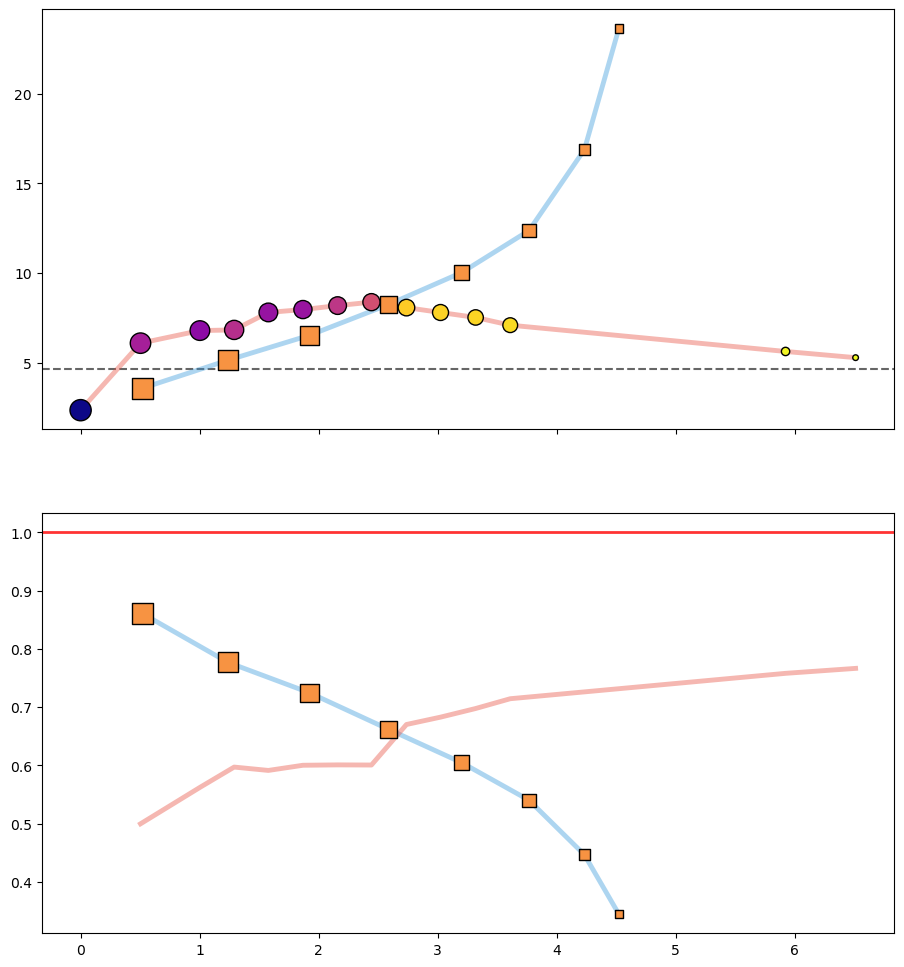

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
from matplotlib.lines import Line2D

# =============================================================================
# CONFIGURATION
# =============================================================================
RESULTS_FILE = "../data/kepler11e_sweep_results.csv"
OUTPUT_PLOT = "../figures/kepler11e_ddc_verification_plot.pdf"

MODES = [
    'Bulk Envelope Transfer',
    'Direct Metal (Total Z = 7.5 M_E)',
    'Direct Metal (Total Z = 7.0 M_E)',
    'Direct Metal (Total Z = 6.0 M_E)',
    'Direct Metal (Total Z = 5.0 M_E)'
]

COLORS_MAP = {
    'Bulk Envelope Transfer': '#3498db',           # Blue
    'Direct Metal (Total Z = 7.5 M_E)': '#e74c3c', # Red
    'Direct Metal (Total Z = 7.0 M_E)': '#f39c12', # Orange
    'Direct Metal (Total Z = 6.0 M_E)': '#9b59b6', # Purple
    'Direct Metal (Total Z = 5.0 M_E)': '#7f8c8d'  # Gray/Slate
}

MARKERS = {
    'Bulk Envelope Transfer': 's', 
    'Direct Metal (Total Z = 7.5 M_E)': 'o',
    'Direct Metal (Total Z = 7.0 M_E)': '^',
    'Direct Metal (Total Z = 6.0 M_E)': 'D',
    'Direct Metal (Total Z = 5.0 M_E)': '<',
}

# =============================================================================
# PLOTTING
# =============================================================================
if not os.path.exists(RESULTS_FILE):
    print(f"[!] Could not find results file at {RESULTS_FILE}")
else:
    df_plot = pd.read_csv(RESULTS_FILE)
    
    # Filter for reasonable radii to avoid failed unbound models
    df_plot = df_plot[df_plot['R_total_Re'] < 25.0]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 12), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 1]})

    # Colorbar scaling for Sigma
    sigma_min_floor = 1e-3
    sigma_max = df_plot['Sigma_Used'].max()
    norm = colors.LogNorm(vmin=sigma_min_floor, vmax=sigma_max)

    sc = None 
    legend_handles = []

    # Add Reference Lines
    obs_line = ax1.axhline(y=4.67, color='black', linestyle='--', alpha=0.6, label='Kepler-11e Obs. Radius', zorder=0)
    ideal_line = ax2.axhline(y=1.0, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Ideal DDC Match (1.0)', zorder=0)
    legend_handles.extend([obs_line, ideal_line])

    for mode in MODES:
        df_mode = df_plot[df_plot['Transfer_Mode'] == mode].copy()
        if df_mode.empty: continue
        df_mode = df_mode.sort_values(by='M_core_Me', ascending=False)
        
        # Scaling point size by Core Mass
        m_min, m_max = 2.0, 8.0
        point_sizes = (df_mode['M_core_Me'] - m_min) / (m_max - m_min) * 200 + 50
        c_values = df_mode['Sigma_Used'].replace(0, sigma_min_floor)

        # Panel 1: Radius vs Dilute Mass
        ax1.plot(df_mode['M_dilute_Me'], df_mode['R_total_Re'], 
                 linestyle='-', color=COLORS_MAP[mode], linewidth=3.5, zorder=1, alpha=0.4)
        
        ax1.scatter(df_mode['M_dilute_Me'], df_mode['R_total_Re'], 
                    c=c_values, cmap='plasma', norm=norm,
                    marker=MARKERS[mode], s=point_sizes, edgecolor='black', 
                    linewidth=1.0, zorder=2)

        # Panel 2: DDC Match Ratio
        # Filter NaNs for the Match Ratio panel
        df_ddc = df_mode.dropna(subset=['DDC_Match_Ratio'])
        if not df_ddc.empty:
            ax2.plot(df_ddc['M_dilute_Me'], df_ddc['DDC_Match_Ratio'], 
                     linestyle='-', color=COLORS_MAP[mode], linewidth=3.5, zorder=1, alpha=0.4)
            
            sc = ax2.scatter(df_ddc['M_dilute_Me'], df_ddc['DDC_Match_Ratio'], 
                             c=df_ddc['Sigma_Used'].replace(0, sigma_min_floor), cmap='plasma', norm=norm,
                             marker=MARKERS[mode], s=point_sizes, edgecolor='black', 
                             linewidth=1.0, zorder=2)
            
        # Add to Legend
        proxy = Line2D([0], [0], color=COLORS_MAP[mode], marker=MARKERS[mode], 
                       linestyle='-', linewidth=3.5, markersize=8, 
                       markerfacecolor='gray', markeredgecolor='black', label=mode)
        legend_handles.append(proxy)

    # Formatting Top Panel
    ax1.set_ylabel(r"Total Planetary Radius ($R_\oplus$)", fontsize=14)
    ax1.set_yscale('log')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Formatting Bottom Panel
    ax2.set_xlabel(r"Dilute Metal Mass in Envelope ($M_\oplus$)", fontsize=14)
    ax2.set_ylabel(r"DDC Match Ratio ($\nabla_{fuzzy} / \nabla_{DDC}$)", fontsize=14)
    #ax2.set_ylim(0.8, 1.2) # Focused window around the theoretical match
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Size legend (Core Mass)
    size_legend = [
        Line2D([0], [0], marker='o', color='w', label=r'$M_{core}=2.0 \ M_\oplus$', 
               markerfacecolor='gray', markersize=np.sqrt(50), markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label=r'$M_{core}=8.0 \ M_\oplus$', 
               markerfacecolor='gray', markersize=np.sqrt(250), markeredgecolor='black')
    ]
    
    ax1.legend(handles=legend_handles + size_legend, fontsize=9, loc='upper left', framealpha=0.9, ncol=2)

    # Global Colorbar for Sigma
    if sc is not None:
        cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation='horizontal', pad=0.1, aspect=50)
        cbar.set_label(r"Compositional Gradient Width ($\sigma$)", fontsize=14)

    plt.tight_layout()
    os.makedirs(os.path.dirname(OUTPUT_PLOT), exist_ok=True)
    plt.savefig(OUTPUT_PLOT, format='pdf', bbox_inches='tight')
    print(f"[*] Plot successfully saved to {OUTPUT_PLOT}")
    plt.show()

Sharp Core Inflation (500K -> 1200K): +0.375 R_J
Fuzzy Core Inflation (500K -> 1200K): +0.359 R_J


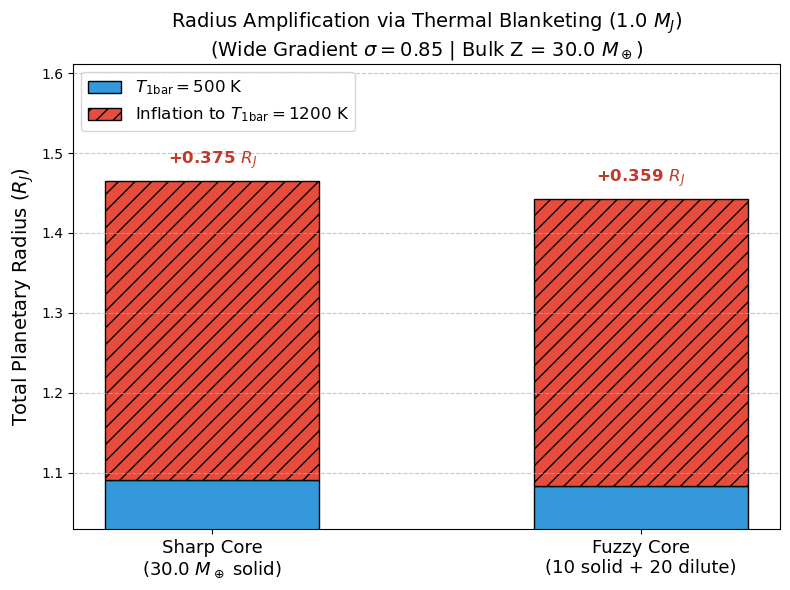

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. Configuration & Constants
# =========================================================================
CSV_FILE = "../scripts/tint_amplification_results.csv"
TARGET_MZ_ME = 30.0 
FIXED_WIDE_SIGMA = 0.85

# =========================================================================
# 2. Data Loading & Processing
# =========================================================================
# Read the saved simulation results
df = pd.read_csv(CSV_FILE)

# Extract the specific radii from the DataFrame
sharp_cold = df[(df['Type'] == 'Sharp') & (df['T_int'] == 500)]['Radius_Rj'].values[0]
sharp_hot  = df[(df['Type'] == 'Sharp') & (df['T_int'] == 1200)]['Radius_Rj'].values[0]

fuzzy_cold = df[(df['Type'] == 'Fuzzy') & (df['T_int'] == 500)]['Radius_Rj'].values[0]
fuzzy_hot  = df[(df['Type'] == 'Fuzzy') & (df['T_int'] == 1200)]['Radius_Rj'].values[0]

# Calculate the inflation deltas
delta_sharp = sharp_hot - sharp_cold
delta_fuzzy = fuzzy_hot - fuzzy_cold

print(f"Sharp Core Inflation (500K -> 1200K): +{delta_sharp:.3f} R_J")
print(f"Fuzzy Core Inflation (500K -> 1200K): +{delta_fuzzy:.3f} R_J")

# =========================================================================
# 3. Plotting the Bar Chart
# =========================================================================
labels = [
    f'Sharp Core\n({TARGET_MZ_ME} $M_\\oplus$ solid)', 
    f'Fuzzy Core\n(10 solid + 20 dilute)'
]
cold_radii = [sharp_cold, fuzzy_cold]
inflations = [delta_sharp, delta_fuzzy]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 6))

# Base Radii (Cold)
ax.bar(x, cold_radii, width, label='$T_{1\\text{bar}} = 500$ K', color='#3498db', edgecolor='black')

# Inflation Delta (Hot)
ax.bar(x, inflations, width, bottom=cold_radii, label='Inflation to $T_{1\\text{bar}} = 1200$ K', 
       color='#e74c3c', hatch='//', edgecolor='black')

# Formatting
ax.set_ylabel('Total Planetary Radius ($R_J$)', fontsize=14)
#ax.set_title(
#    f'Radius Amplification via Thermal Blanketing ($1.0\\ M_J$)\n'
#    f'(Wide Gradient $\\sigma={FIXED_WIDE_SIGMA}$ | Bulk Z = {TARGET_MZ_ME} $M_\\oplus$)', 
#    fontsize=14
#)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Dynamically set y-axis limits to highlight the differences AND give headroom for labels/legend
max_height = max(sharp_hot, fuzzy_hot)
ax.set_ylim(bottom=min(cold_radii) * 0.95, top=max_height * 1.10) # <-- Added top margin here

# Annotate Delta R at the top of the bars
ax.text(0, sharp_hot + 0.02, f"+{delta_sharp:.3f} $R_J$", ha='center', fontsize=12, fontweight='bold', color='#c0392b')
ax.text(1, fuzzy_hot + 0.02, f"+{delta_fuzzy:.3f} $R_J$", ha='center', fontsize=12, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.savefig("../figures/tint_amplification_bar.pdf", format='pdf', bbox_inches='tight')
plt.show()